## Setup — imports, paths, output folder

In [2]:
import pandas as pd
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt

from dowhy import CausalModel
from econml.dml import CausalForestDML

# Output folder for all BBB RQ2 visualizations
OUTPUT_DIR = r"C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Raw BBB module CSV (merged from 2013B, 2013J, 2014B; 2014J excluded — mismatched assessment count)
DATA_PATH = r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\BBB.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(5617, 46)


,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,clicks_glossary,clicks_homepage,clicks_oucollaborate,clicks_oucontent,clicks_ouelluminate,clicks_quiz,clicks_resource,clicks_sharedsubpage,clicks_subpage,clicks_url
0,2013B,23629,F,East Anglian Region,Lower Than A Level,20-30%,0-35,2,60,N,...,0.0,36.0,NaN,0.0,0.0,31.0,2.0,0.0,5.0,0.0
1,2013B,25107,F,East Anglian Region,Lower Than A Level,20-30%,0-35,0,120,N,...,2.0,831.0,NaN,1.0,1.0,85.0,23.0,0.0,21.0,14.0
2,2013B,27891,M,Scotland,Lower Than A Level,0-10%,0-35,2,120,Y,...,0.0,66.0,NaN,1.0,0.0,38.0,6.0,0.0,11.0,6.0
3,2013B,29144,M,South Region,Lower Than A Level,60-70%,0-35,0,120,N,...,2.0,556.0,NaN,3.0,0.0,78.0,358.0,0.0,442.0,39.0
4,2013B,31663,M,North Region,A Level or Equivalent,30-40%,35-55,0,60,N,...,3.0,1341.0,NaN,1.0,11.0,69.0,230.0,0.0,234.0,56.0


## Preprocessing — imd_band fix, encodings, quartile binning, total_clicks composite

In [7]:
from sklearn.preprocessing import LabelEncoder

df_sel = df.copy()

# imd_band bug fix: '10-20' missing '%' sign
df_sel['imd_band'] = df_sel['imd_band'].replace('10-20', '10-20%')
imd_mode = df_sel['imd_band'].mode()[0]
df_sel['imd_band'] = df_sel['imd_band'].fillna(imd_mode)

# Ordinal: final_result
final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
df_sel['final_result'] = df_sel['final_result'].map(final_result_map)

# Ordinal: highest_education
highest_education_map = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}
df_sel['highest_education'] = df_sel['highest_education'].map(highest_education_map)

# Ordinal: imd_band
imd_band_map = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
df_sel['imd_band'] = df_sel['imd_band'].map(imd_band_map)

# Ordinal: age_band
age_band_map = {'0-35': 0, '35-55': 1, '55<=': 2}
df_sel['age_band'] = df_sel['age_band'].map(age_band_map)

# Binary: gender, disability
df_sel['gender'] = df_sel['gender'].map({'F': 0, 'M': 1})
df_sel['disability'] = df_sel['disability'].map({'N': 0, 'Y': 1})

# Label encode: region
le = LabelEncoder()
df_sel['region'] = le.fit_transform(df_sel['region'])

print(df_sel.isna().sum().sum())
df_sel.dtypes

71130


code_presentation        object
id_student                int64
gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability                int64
final_result              int64
date_registration       float64
date_unregistration     float64
ass_1_date              float64
ass_1_score             float64
ass_2_date              float64
ass_2_score             float64
ass_3_date              float64
ass_3_score             float64
ass_4_date              float64
ass_4_score             float64
ass_5_date              float64
ass_5_score             float64
ass_6_date              float64
ass_6_score             float64
ass_7_date              float64
ass_7_score             float64
ass_8_date              float64
ass_8_score             float64
ass_9_date              float64
ass_9_score             float64
ass_10_d

## Assessment scores — NaN fill and quartile binning (ass_1 through ass_11)

In [10]:
assessment_cols = [c for c in df_sel.columns if c.startswith('ass_') and c.endswith('_score')]
print(assessment_cols)

# Non-submission -> -1 (as in RQ1 pipeline), then quartile-bin
for col in assessment_cols:
    df_sel[col] = df_sel[col].fillna(-1)
    try:
        df_sel[col] = pd.qcut(df_sel[col], q=4, labels=False, duplicates='drop')
    except ValueError as e:
        print(f"{col}: binning issue -> {e}")

for col in assessment_cols:
    print(col, df_sel[col].nunique(), "bins")

['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score', 'ass_10_score', 'ass_11_score']
ass_1_score 4 bins
ass_2_score 3 bins
ass_3_score 3 bins
ass_4_score 3 bins
ass_5_score 3 bins
ass_6_score 2 bins
ass_7_score 2 bins
ass_8_score 2 bins
ass_9_score 2 bins
ass_10_score 2 bins
ass_11_score 1 bins


## Click columns — variation check, total_clicks composite, quartile binning

In [13]:
click_cols = [c for c in df_sel.columns if c.startswith('clicks_')]
print(click_cols)

# Fill missing clicks with 0 (no engagement recorded)
for col in click_cols:
    df_sel[col] = df_sel[col].fillna(0)

# Variation check on raw click columns before collapsing
for col in click_cols:
    print(col, "nonzero:", (df_sel[col] > 0).sum(), "| unique vals:", df_sel[col].nunique())

['clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouelluminate', 'clicks_quiz', 'clicks_resource', 'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url']
clicks_forumng nonzero: 4345 | unique vals: 1183
clicks_glossary nonzero: 1364 | unique vals: 27
clicks_homepage nonzero: 4686 | unique vals: 732
clicks_oucollaborate nonzero: 681 | unique vals: 19
clicks_oucontent nonzero: 3493 | unique vals: 143
clicks_ouelluminate nonzero: 451 | unique vals: 23
clicks_quiz nonzero: 4095 | unique vals: 223
clicks_resource nonzero: 4421 | unique vals: 219
clicks_sharedsubpage nonzero: 128 | unique vals: 7
clicks_subpage nonzero: 4553 | unique vals: 273
clicks_url nonzero: 4375 | unique vals: 139


## total_clicks composite — sum raw clicks, quartile-bin, drop individual columns

In [16]:
# Sum raw click counts (before binning individual columns) into total_clicks
df_sel['total_clicks'] = df_sel[click_cols].sum(axis=1)

# Quartile-bin the composite
df_sel['total_clicks'] = pd.qcut(df_sel['total_clicks'], q=4, labels=False, duplicates='drop')

print(df_sel['total_clicks'].nunique(), "bins")
print(df_sel['total_clicks'].value_counts().sort_index())

# Drop individual click columns from df_sel (kept separately in raw df for DAG3/DAG4 later)
df_sel = df_sel.drop(columns=click_cols)

df_sel.shape

4 bins
total_clicks
0    1410
1    1405
2    1399
3    1403
Name: count, dtype: int64


## Final modeling variable set — drop identifiers and date columns

In [19]:
date_cols = [c for c in df_sel.columns if c.endswith('_date')] + ['date_registration', 'date_unregistration']
id_cols = ['code_presentation', 'id_student']

df_model = df_sel.drop(columns=date_cols + id_cols)

print(df_model.shape)
df_model.columns.tolist()

(5617, 21)


['gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'disability',
 'final_result',
 'ass_1_score',
 'ass_2_score',
 'ass_3_score',
 'ass_4_score',
 'ass_5_score',
 'ass_6_score',
 'ass_7_score',
 'ass_8_score',
 'ass_9_score',
 'ass_10_score',
 'ass_11_score',
 'total_clicks']

## Build BBB combined DAG in networkx, derive adjustment sets programmatically

In [22]:
edges = [
    ('gender', 'age_band'),
    ('highest_education', 'region'),
    ('region', 'imd_band'),
    ('age_band', 'highest_education'),
    ('disability', 'highest_education'),
    ('age_band', 'total_clicks'),
    ('ass_1_score', 'ass_2_score'),
    ('ass_1_score', 'ass_3_score'),
    ('ass_1_score', 'ass_4_score'),
    ('ass_1_score', 'ass_5_score'),
    ('ass_1_score', 'ass_7_score'),
    ('ass_1_score', 'ass_9_score'),
    ('ass_1_score', 'final_result'),
    ('total_clicks', 'ass_1_score'),
    ('ass_2_score', 'ass_3_score'),
    ('ass_2_score', 'ass_4_score'),
    ('ass_2_score', 'ass_5_score'),
    ('ass_2_score', 'ass_7_score'),
    ('ass_2_score', 'final_result'),
    ('total_clicks', 'ass_2_score'),
    ('ass_3_score', 'ass_4_score'),
    ('ass_3_score', 'ass_5_score'),
    ('ass_3_score', 'ass_6_score'),
    ('ass_3_score', 'ass_8_score'),
    ('ass_3_score', 'ass_9_score'),
    ('ass_3_score', 'final_result'),
    ('total_clicks', 'ass_3_score'),
    ('ass_4_score', 'ass_5_score'),
    ('ass_4_score', 'ass_6_score'),
    ('ass_4_score', 'ass_9_score'),
    ('ass_4_score', 'ass_10_score'),
    ('ass_4_score', 'final_result'),
    ('ass_5_score', 'ass_6_score'),
    ('ass_5_score', 'ass_10_score'),
    ('ass_5_score', 'final_result'),
    ('total_clicks', 'ass_5_score'),
    ('ass_6_score', 'final_result'),
    ('ass_7_score', 'ass_8_score'),
    ('ass_7_score', 'ass_9_score'),
    ('total_clicks', 'ass_7_score'),
    ('ass_8_score', 'ass_9_score'),
    ('ass_8_score', 'ass_10_score'),
    ('ass_8_score', 'final_result'),
    ('total_clicks', 'ass_8_score'),
    ('ass_9_score', 'ass_10_score'),
    ('ass_9_score', 'final_result'),
    ('total_clicks', 'ass_9_score'),
    ('total_clicks', 'ass_10_score'),
    ('total_clicks', 'final_result'),
]
# Undirected/Markov-equivalent pairs — excluded from directed graph, noted separately
undirected_pairs = [('imd_band', 'disability'), ('num_of_prev_attempts', 'studied_credits')]

G = nx.DiGraph()
G.add_edges_from(edges)

# Treatments = any node with a directed path to final_result, excluding final_result itself and isolated ass_11_score
candidates = [n for n in G.nodes() if n != 'final_result']
treatments = [n for n in candidates if nx.has_path(G, n, 'final_result')]

print("Treatments with a path to final_result:", treatments)
print("\nExcluded (no path to final_result):", [n for n in candidates if n not in treatments])

# Adjustment set = direct parents of each treatment
adjustment_sets = {t: list(G.predecessors(t)) for t in treatments}
for t, adj in adjustment_sets.items():
    print(t, "->", adj)

Treatments with a path to final_result: ['gender', 'age_band', 'total_clicks', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_7_score', 'ass_9_score', 'ass_6_score', 'ass_8_score']

Excluded (no path to final_result): ['highest_education', 'region', 'imd_band', 'disability', 'ass_10_score']
gender -> []
age_band -> ['gender']
total_clicks -> ['age_band']
ass_1_score -> ['total_clicks']
ass_2_score -> ['ass_1_score', 'total_clicks']
ass_3_score -> ['ass_1_score', 'ass_2_score', 'total_clicks']
ass_4_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score']
ass_5_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'total_clicks']
ass_7_score -> ['ass_1_score', 'ass_2_score', 'total_clicks']
ass_9_score -> ['ass_1_score', 'ass_3_score', 'ass_4_score', 'ass_7_score', 'ass_8_score', 'total_clicks']
ass_6_score -> ['ass_3_score', 'ass_4_score', 'ass_5_score']
ass_8_score -> ['ass_3_score', 'ass_7_score', 'total_clicks']


## Display BBB combined-variable RQ1 DAG for reference

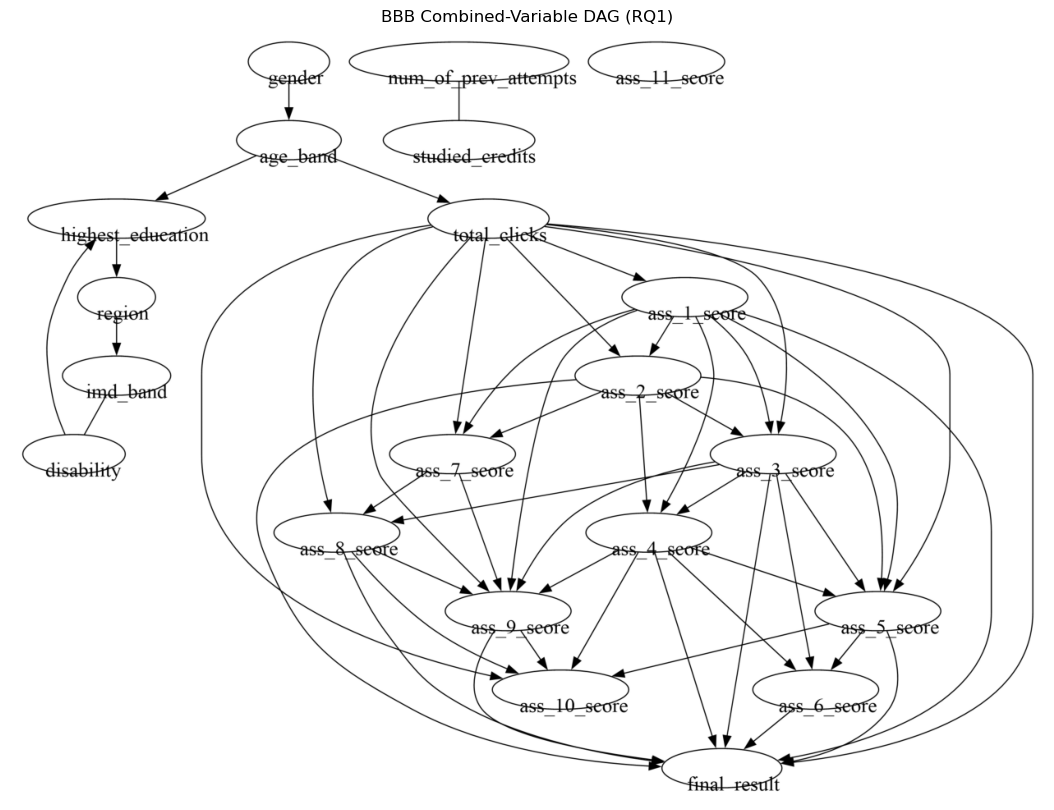

In [25]:
from PIL import Image

dag_image_path = r"C:\Users\Disha Sharma\Desktop\Paper_1\BBB_DAG.png" 
img = Image.open(dag_image_path)

plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis('off')
plt.title("BBB Combined-Variable DAG (RQ1)")
plt.show()

## DoWhy ATE loop — all 12 treatments, with 95% confidence intervals

In [28]:
results = []  # reset before rerun — avoids duplicate rows on reruns

for treatment in treatments:
    common_causes = adjustment_sets[treatment]

    model = CausalModel(
        data=df_model,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    results.append({
        'treatment': treatment,
        'adjustment_set': common_causes,
        'ATE': ate,
        'CI_lower': ci_low,
        'CI_upper': ci_high,
        'significant': significant
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

results_df = pd.DataFrame(results)
results_df

gender: ATE=0.005, CI=[-0.076, 0.085], significant=False
age_band: ATE=0.180, CI=[0.125, 0.234], significant=True
total_clicks: ATE=0.579, CI=[0.562, 0.596], significant=True
ass_1_score: ATE=0.251, CI=[0.229, 0.272], significant=True
ass_2_score: ATE=0.289, CI=[0.259, 0.319], significant=True
ass_3_score: ATE=0.470, CI=[0.441, 0.500], significant=True
ass_4_score: ATE=0.547, CI=[0.518, 0.575], significant=True
ass_5_score: ATE=0.448, CI=[0.419, 0.477], significant=True
ass_7_score: ATE=0.284, CI=[0.239, 0.329], significant=True
ass_9_score: ATE=0.249, CI=[0.206, 0.292], significant=True
ass_6_score: ATE=0.153, CI=[0.109, 0.197], significant=True
ass_8_score: ATE=0.175, CI=[0.133, 0.216], significant=True


,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,gender,[],0.004574,-0.075583,0.084732,False
1,age_band,[gender],0.179709,0.125483,0.233936,True
2,total_clicks,[age_band],0.579149,0.561912,0.596385,True
3,ass_1_score,[total_clicks],0.250548,0.229252,0.271843,True
4,ass_2_score,"[ass_1_score, total_clicks]",0.288651,0.258741,0.318560,True
5,ass_3_score,"[ass_1_score, ass_2_score, total_clicks]",0.470475,0.440570,0.500380,True
6,ass_4_score,"[ass_1_score, ass_2_score, ass_3_score]",0.546612,0.517730,0.575494,True
7,ass_5_score,"[ass_1_score, ass_2_score, ass_3_score, ass_4_...",0.447992,0.419285,0.476700,True
8,ass_7_score,"[ass_1_score, ass_2_score, total_clicks]",0.284074,0.239478,0.328669,True
9,ass_9_score,"[ass_1_score, ass_3_score, ass_4_score, ass_7_...",0.249056,0.205700,0.292412,True


## Refutation — placebo treatment + random common cause, all 12 treatments

In [31]:
refutation_results = []  # reset before rerun

for treatment in treatments:
    common_causes = adjustment_sets[treatment]

    model = CausalModel(
        data=df_model,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    original_ate = estimate.value

    # Placebo treatment refuter — run alone per treatment (DoWhy 0.14 bug with multiple simultaneous treatments)
    placebo_refute = model.refute_estimate(
        identified_estimand,
        estimate,
        method_name="placebo_treatment_refuter",
        placebo_type="permute"
    )

    # Random common cause refuter
    random_cause_refute = model.refute_estimate(
        identified_estimand,
        estimate,
        method_name="random_common_cause"
    )

    refutation_results.append({
        'treatment': treatment,
        'original_ATE': original_ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'placebo_p_value': placebo_refute.refutation_result.get('p_value', None) if hasattr(placebo_refute, 'refutation_result') else None,
        'random_cause_new_effect': random_cause_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - original_ate)
    })

    print(f"{treatment}: placebo_effect={placebo_refute.new_effect:.4f}, random_cause_effect={random_cause_refute.new_effect:.4f}")

refutation_df = pd.DataFrame(refutation_results)
refutation_df

gender: placebo_effect=-0.0055, random_cause_effect=0.0046
age_band: placebo_effect=0.0012, random_cause_effect=0.1797
total_clicks: placebo_effect=-0.0005, random_cause_effect=0.5792
ass_1_score: placebo_effect=-0.0003, random_cause_effect=0.2506
ass_2_score: placebo_effect=0.0000, random_cause_effect=0.2886
ass_3_score: placebo_effect=0.0008, random_cause_effect=0.4705
ass_4_score: placebo_effect=0.0012, random_cause_effect=0.5466
ass_5_score: placebo_effect=0.0003, random_cause_effect=0.4480
ass_7_score: placebo_effect=-0.0036, random_cause_effect=0.2840
ass_9_score: placebo_effect=-0.0008, random_cause_effect=0.2491
ass_6_score: placebo_effect=-0.0028, random_cause_effect=0.1526
ass_8_score: placebo_effect=0.0015, random_cause_effect=0.1746


,treatment,original_ATE,placebo_new_effect,placebo_p_value,random_cause_new_effect,random_cause_diff
0,gender,0.004574,-0.005510,0.86,0.004597,0.000022
1,age_band,0.179709,0.001205,0.92,0.179717,0.000008
2,total_clicks,0.579149,-0.000536,0.90,0.579161,0.000013
3,ass_1_score,0.250548,-0.000325,1.00,0.250551,0.000003
4,ass_2_score,0.288651,0.000005,0.90,0.288617,0.000034
5,ass_3_score,0.470475,0.000833,0.90,0.470480,0.000005
6,ass_4_score,0.546612,0.001207,0.92,0.546640,0.000029
7,ass_5_score,0.447992,0.000313,0.94,0.447978,0.000014
8,ass_7_score,0.284074,-0.003620,0.88,0.283999,0.000074
9,ass_9_score,0.249056,-0.000804,0.94,0.249086,0.000029


## EconML CausalForestDML — CATE setup, age_band vs imd_band moderators

In [37]:
cate_results = []  # reset before rerun
moderators = ['age_band', 'imd_band']

for treatment in treatments:
    adj_set = adjustment_sets[treatment]

    for moderator in moderators:
        if treatment == moderator:
            continue  # exclude a variable as its own moderator

        W_cols = [c for c in adj_set if c != moderator]

        X = df_model[[moderator]].values
        T = df_model[treatment].values
        Y = df_model['final_result'].values
        W = df_model[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        cate_values = est.effect(X)

        cate_results.append({
            'treatment': treatment,
            'moderator': moderator,
            'W_cols': W_cols,
            'CATE_mean': cate_values.mean(),
            'CATE_min': cate_values.min(),
            'CATE_max': cate_values.max(),
            'CATE_std': cate_values.std()
        })

        print(f"{treatment} | moderator={moderator}: mean={cate_values.mean():.3f}, std={cate_values.std():.3f}")

cate_df = pd.DataFrame(cate_results)
cate_df

gender | moderator=age_band: mean=0.026, std=0.171
gender | moderator=imd_band: mean=0.018, std=0.097
age_band | moderator=imd_band: mean=0.160, std=0.103
total_clicks | moderator=age_band: mean=0.578, std=0.009
total_clicks | moderator=imd_band: mean=0.571, std=0.041
ass_1_score | moderator=age_band: mean=0.230, std=0.015
ass_1_score | moderator=imd_band: mean=0.221, std=0.036
ass_2_score | moderator=age_band: mean=0.313, std=0.047
ass_2_score | moderator=imd_band: mean=0.288, std=0.038
ass_3_score | moderator=age_band: mean=0.461, std=0.012
ass_3_score | moderator=imd_band: mean=0.471, std=0.082
ass_4_score | moderator=age_band: mean=0.489, std=0.029
ass_4_score | moderator=imd_band: mean=0.470, std=0.064
ass_5_score | moderator=age_band: mean=0.443, std=0.005
ass_5_score | moderator=imd_band: mean=0.445, std=0.056
ass_7_score | moderator=age_band: mean=0.226, std=0.029
ass_7_score | moderator=imd_band: mean=0.274, std=0.128
ass_9_score | moderator=age_band: mean=0.250, std=0.037
ass

,treatment,moderator,W_cols,CATE_mean,CATE_min,CATE_max,CATE_std
0,gender,age_band,[],0.025583,-0.218499,0.145357,0.170982
1,gender,imd_band,[],0.018246,-0.107569,0.274587,0.097017
2,age_band,imd_band,[gender],0.160264,-0.007197,0.359398,0.103277
3,total_clicks,age_band,[],0.577992,0.565543,0.584101,0.008720
4,total_clicks,imd_band,[age_band],0.570549,0.505140,0.646029,0.040545
5,ass_1_score,age_band,[total_clicks],0.229833,0.219224,0.251454,0.015145
6,ass_1_score,imd_band,[total_clicks],0.221241,0.172582,0.283523,0.035527
7,ass_2_score,age_band,"[ass_1_score, total_clicks]",0.313267,0.280395,0.380255,0.046926
8,ass_2_score,imd_band,"[ass_1_score, total_clicks]",0.287734,0.231088,0.371321,0.037642
9,ass_3_score,age_band,"[ass_1_score, ass_2_score, total_clicks]",0.460595,0.452086,0.477935,0.012146


## CATE point + 95% CI plots by moderator bin — looped, saved per treatment

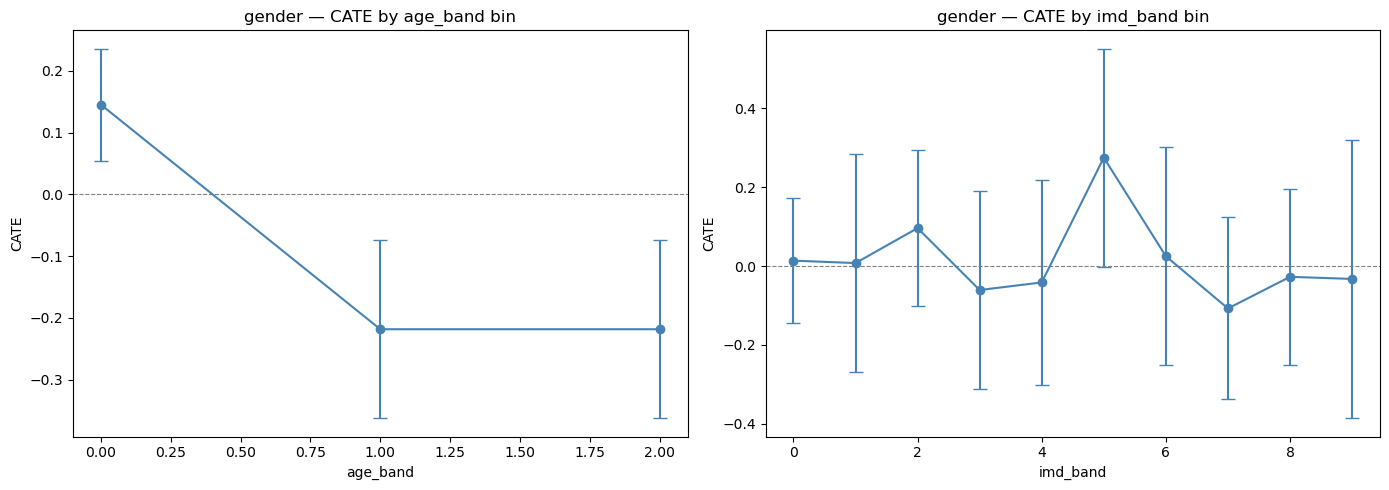

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATE_gender.png


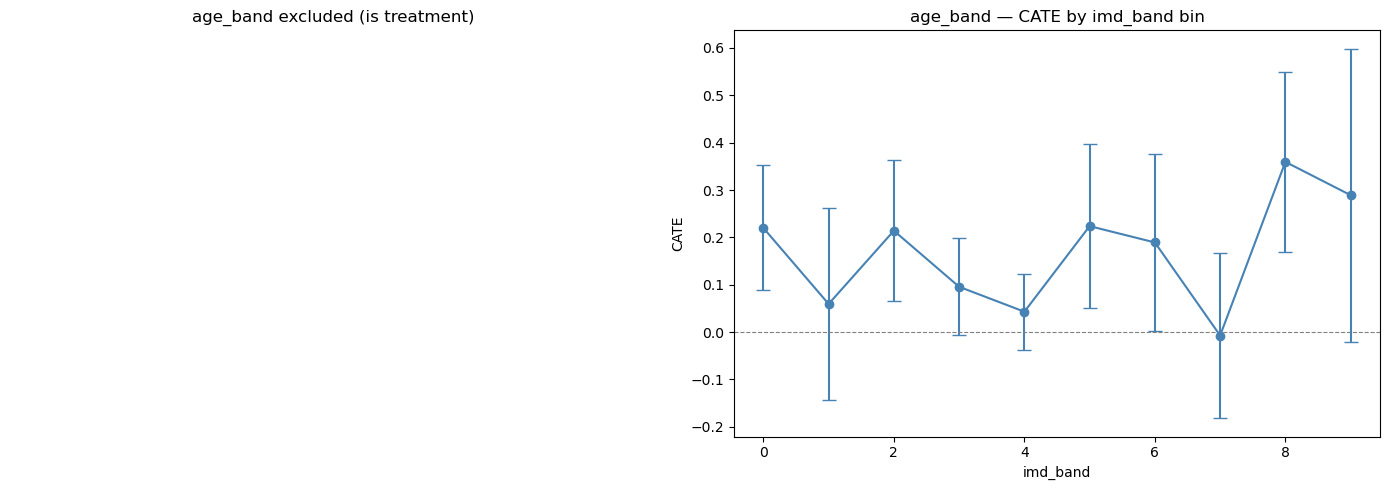

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATE_age_band.png


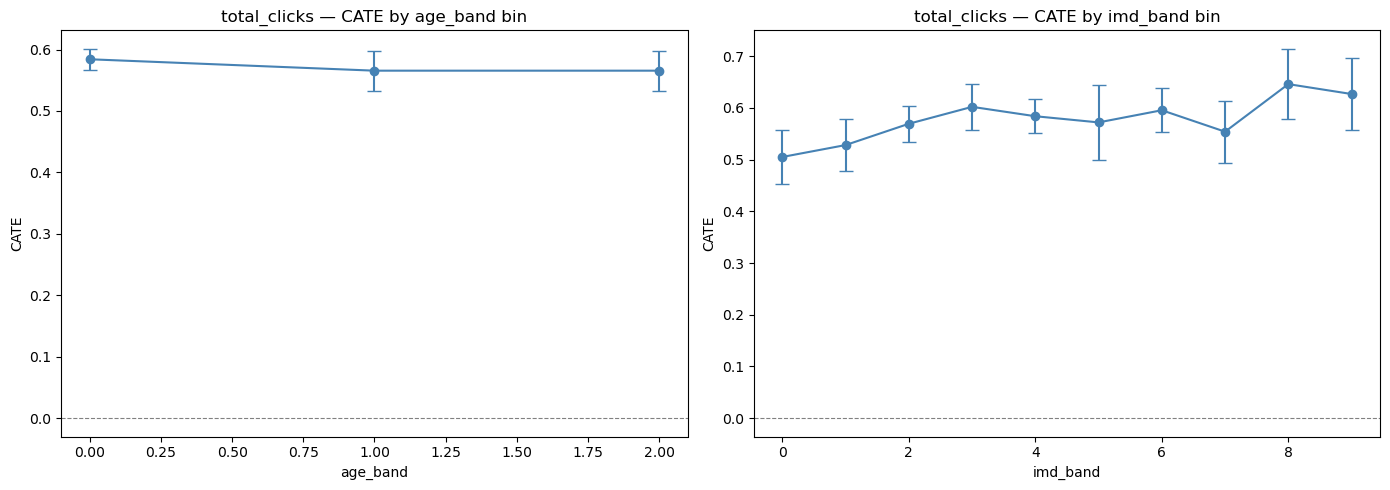

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATE_total_clicks.png


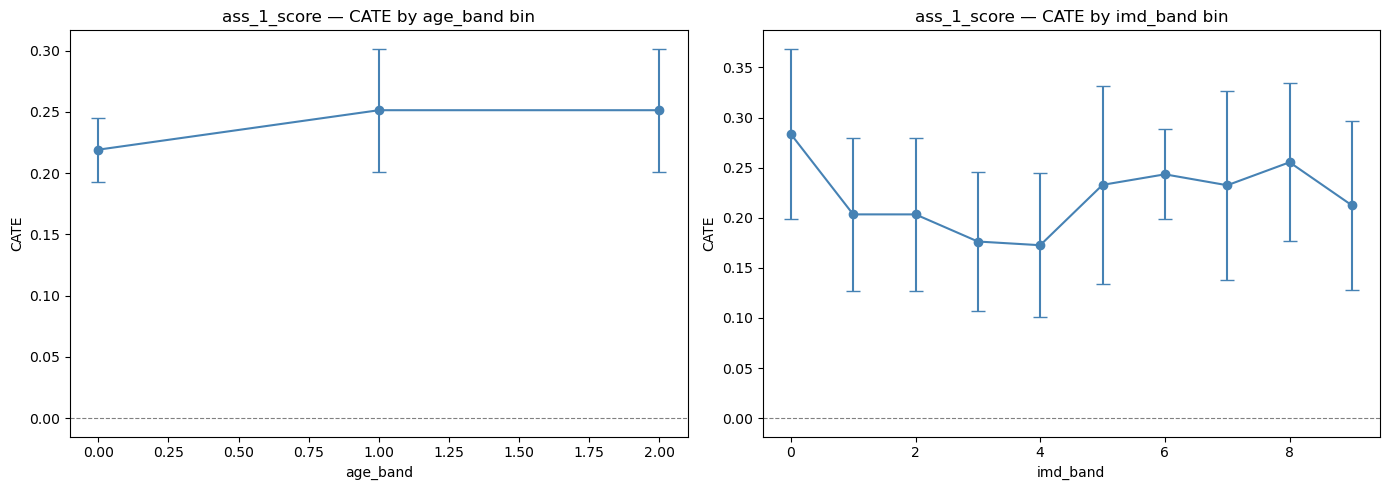

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATE_ass_1_score.png


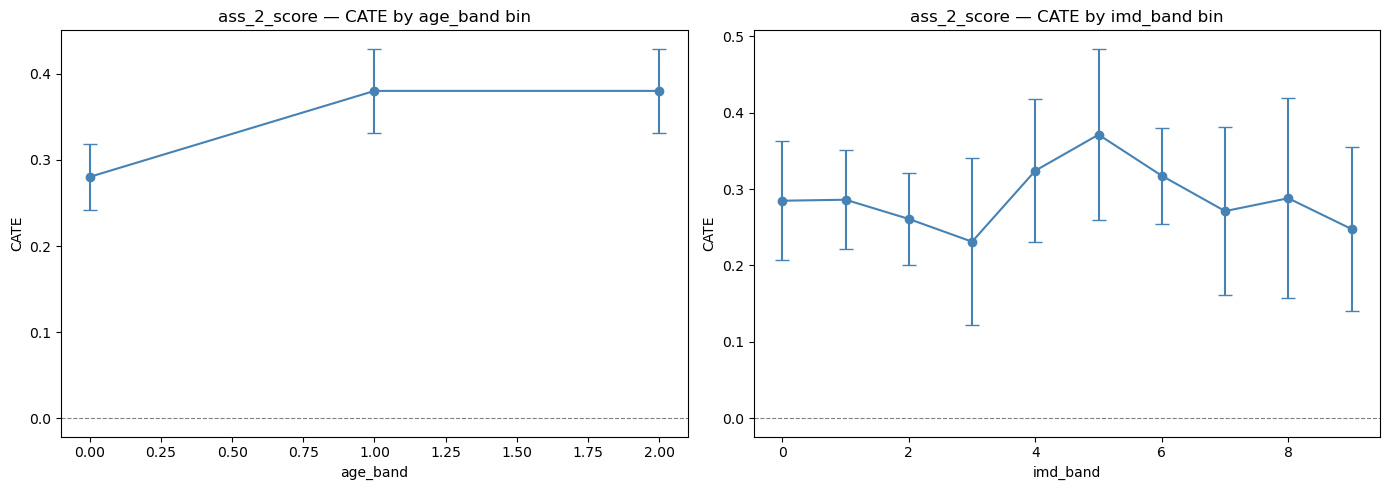

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATE_ass_2_score.png


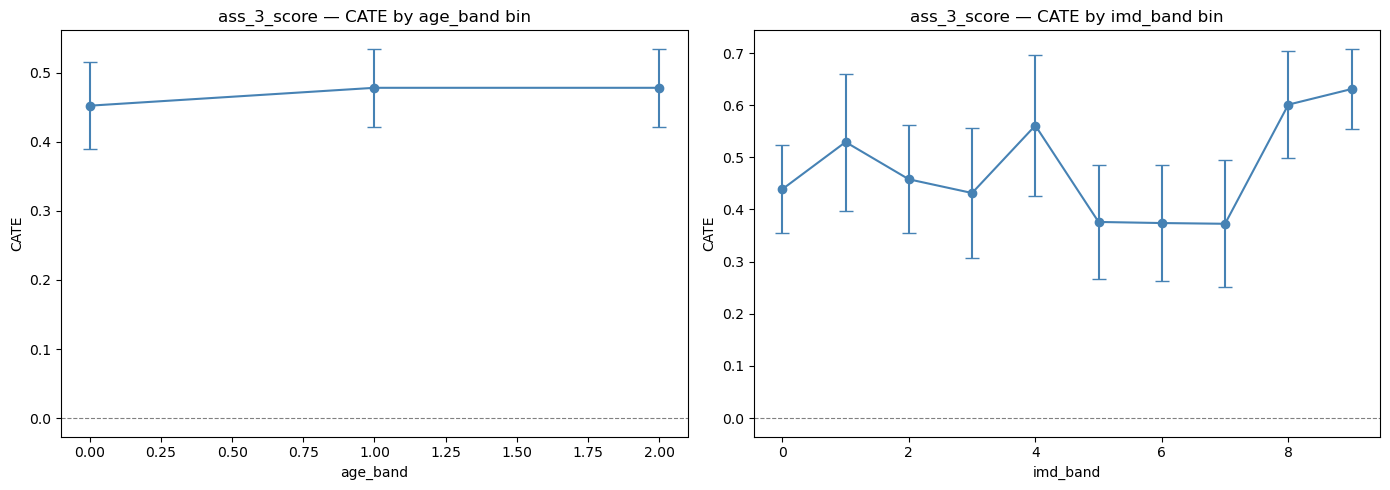

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATE_ass_3_score.png


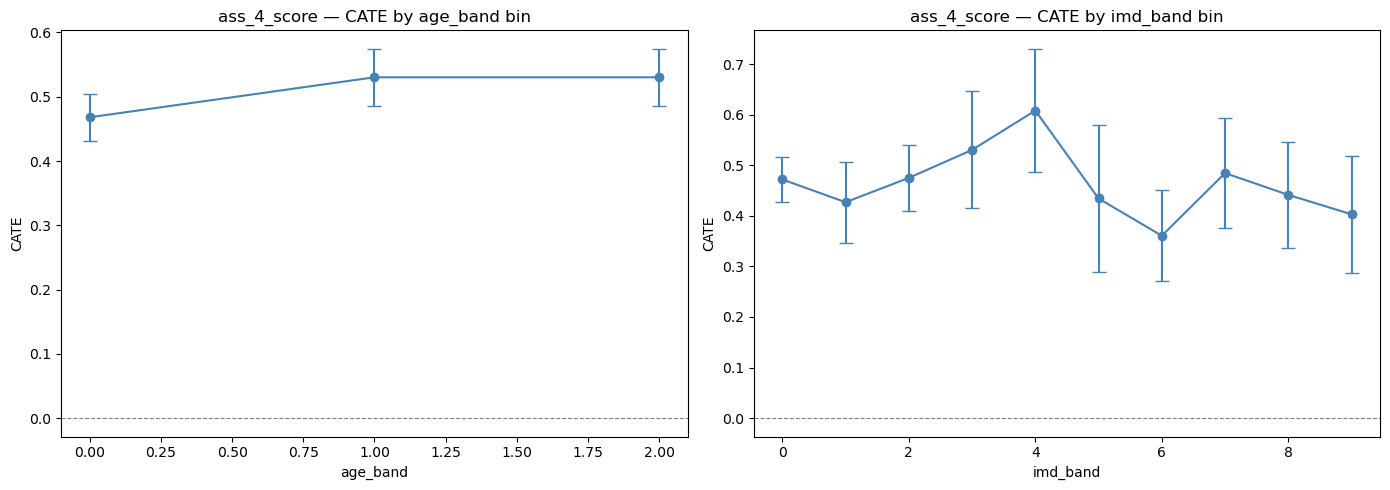

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATE_ass_4_score.png


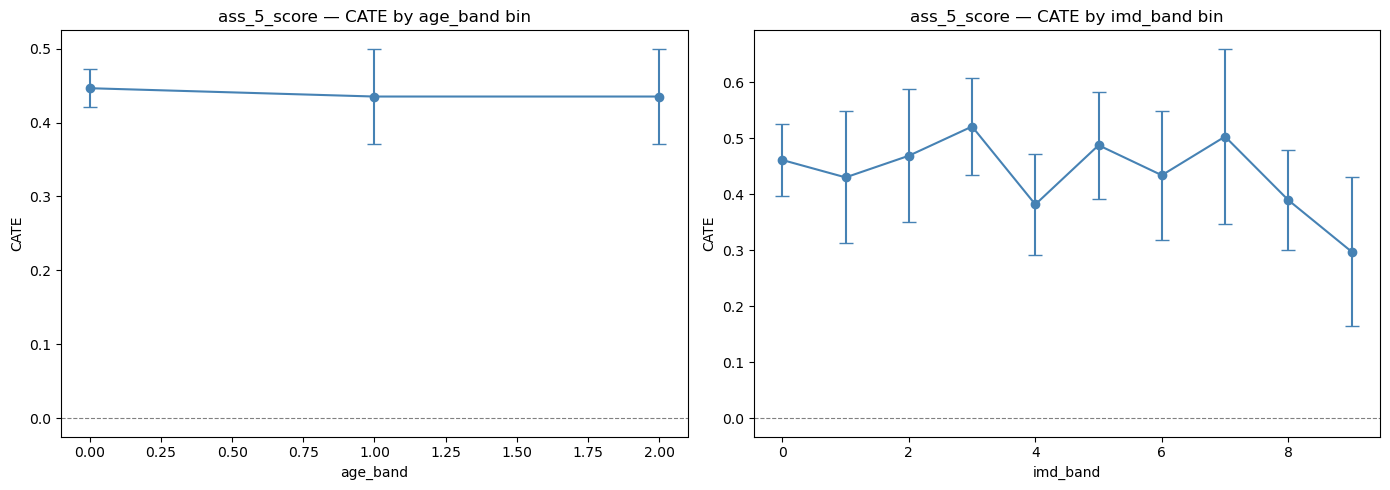

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATE_ass_5_score.png


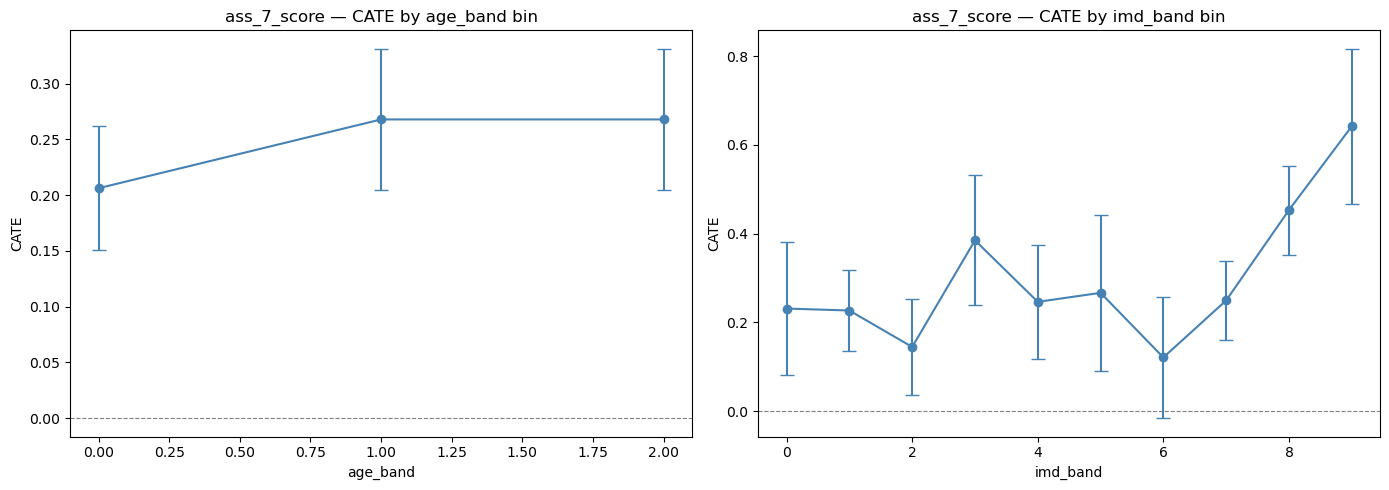

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATE_ass_7_score.png


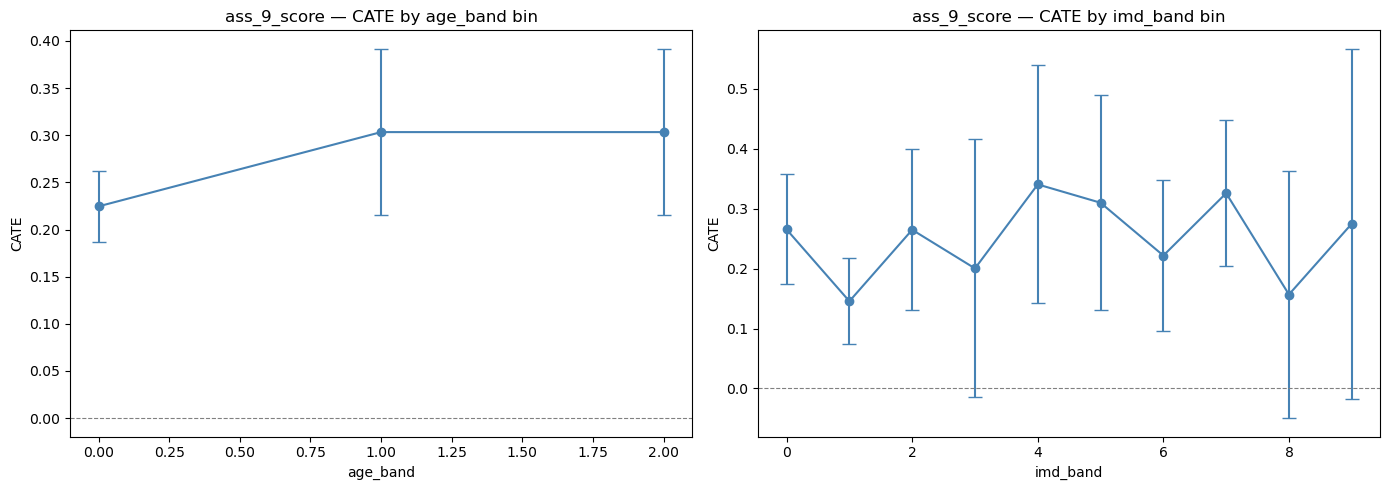

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATE_ass_9_score.png


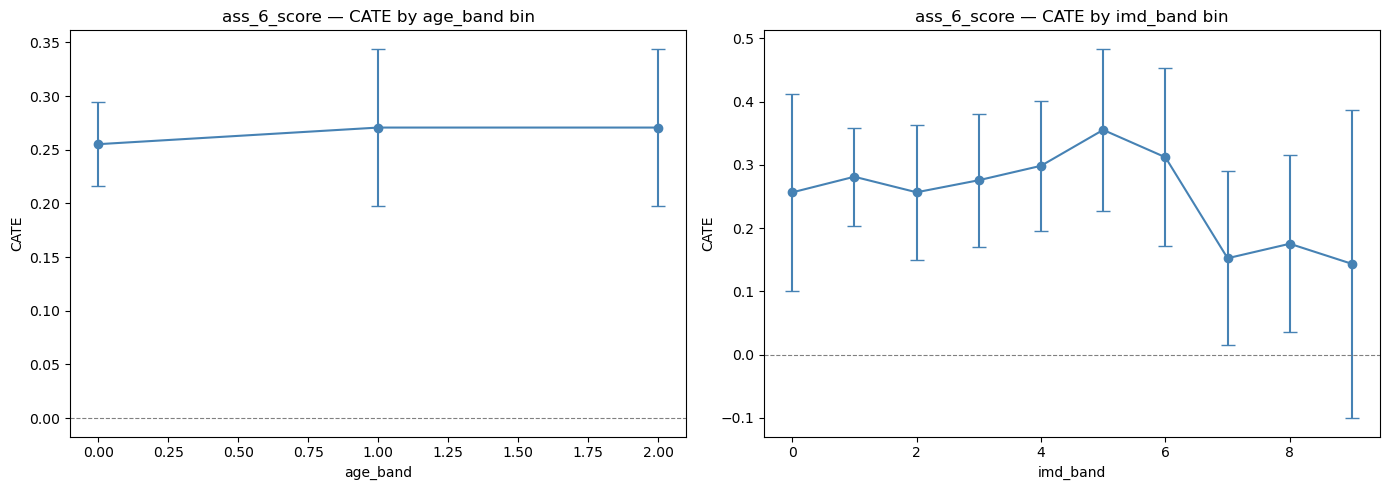

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATE_ass_6_score.png


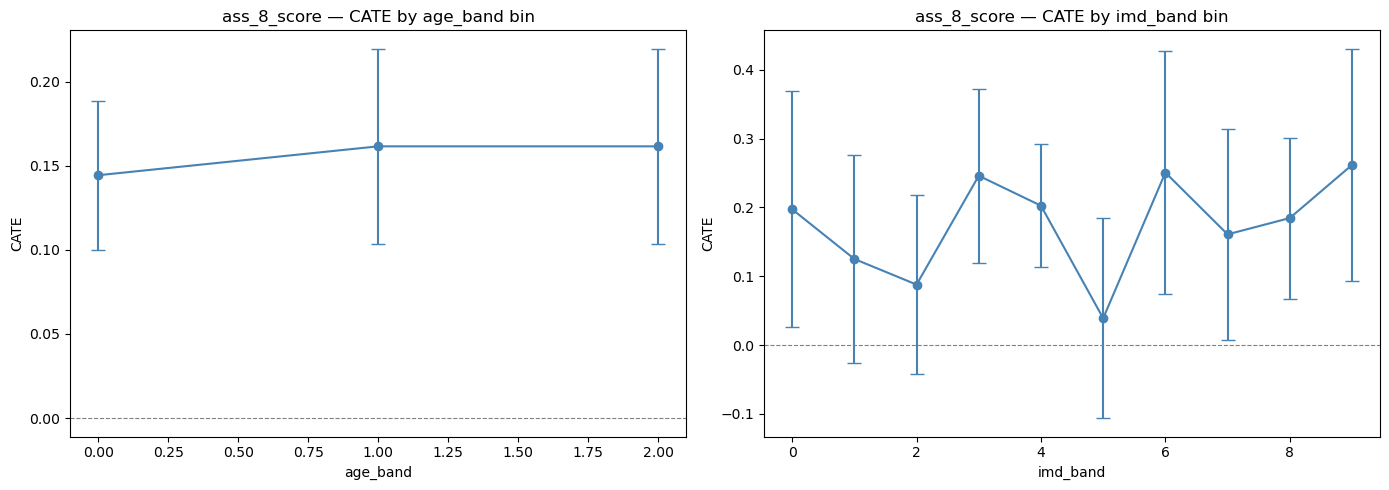

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATE_ass_8_score.png


In [40]:
from scipy import stats

for treatment in treatments:
    adj_set = adjustment_sets[treatment]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, moderator in zip(axes, moderators):
        if treatment == moderator:
            ax.axis('off')
            ax.set_title(f"{moderator} excluded (is treatment)")
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_model[[moderator]].values
        T = df_model[treatment].values
        Y = df_model['final_result'].values
        W = df_model[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        bin_values = sorted(df_model[moderator].unique())
        X_bins = np.array(bin_values).reshape(-1, 1)

        point_estimates = est.effect(X_bins)
        lb, ub = est.effect_interval(X_bins, alpha=0.05)

        yerr = np.array([point_estimates - lb, ub - point_estimates])

        ax.errorbar(bin_values, point_estimates, yerr=yerr, fmt='o-', capsize=5, color='steelblue')
        ax.set_xlabel(moderator)
        ax.set_ylabel('CATE')
        ax.set_title(f'{treatment} — CATE by {moderator} bin')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"BBB_CATE_{treatment}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

    print(f"Saved: {save_path}")

## Policy tree — total_clicks only, both moderators, cost=0 (illustrative)

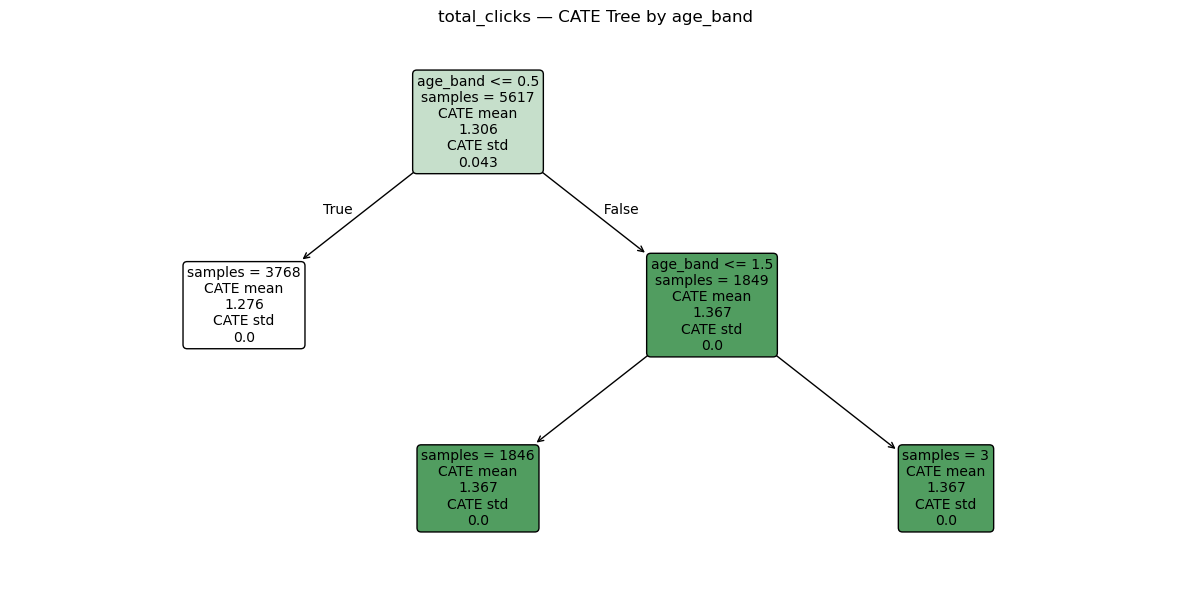

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATEtree_total_clicks_age_band.png


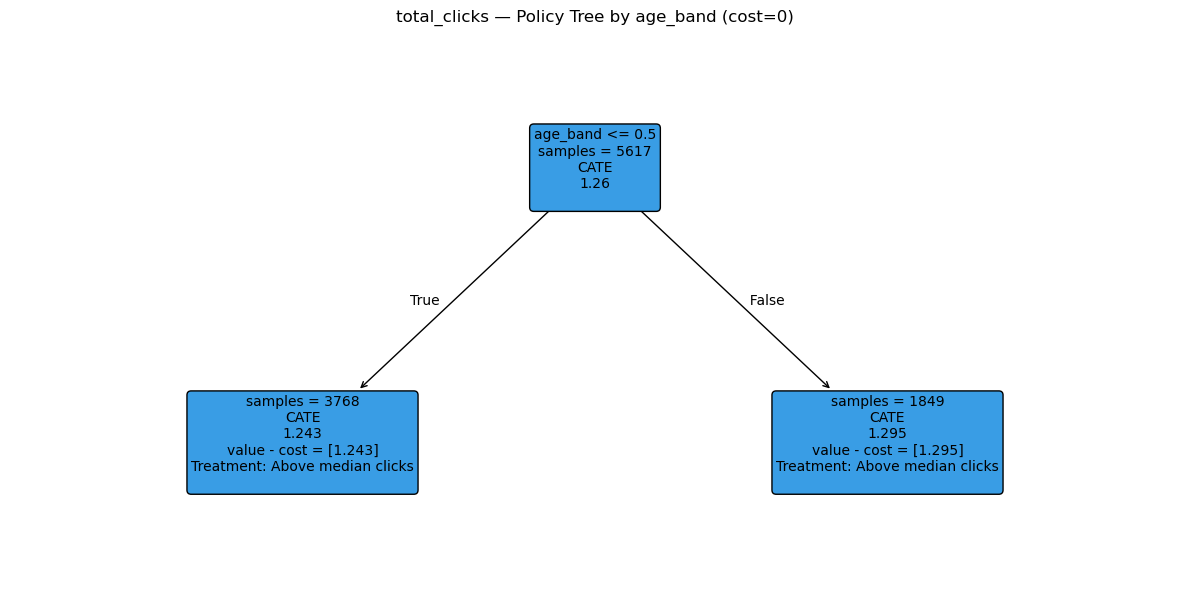

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_policy_total_clicks_age_band.png


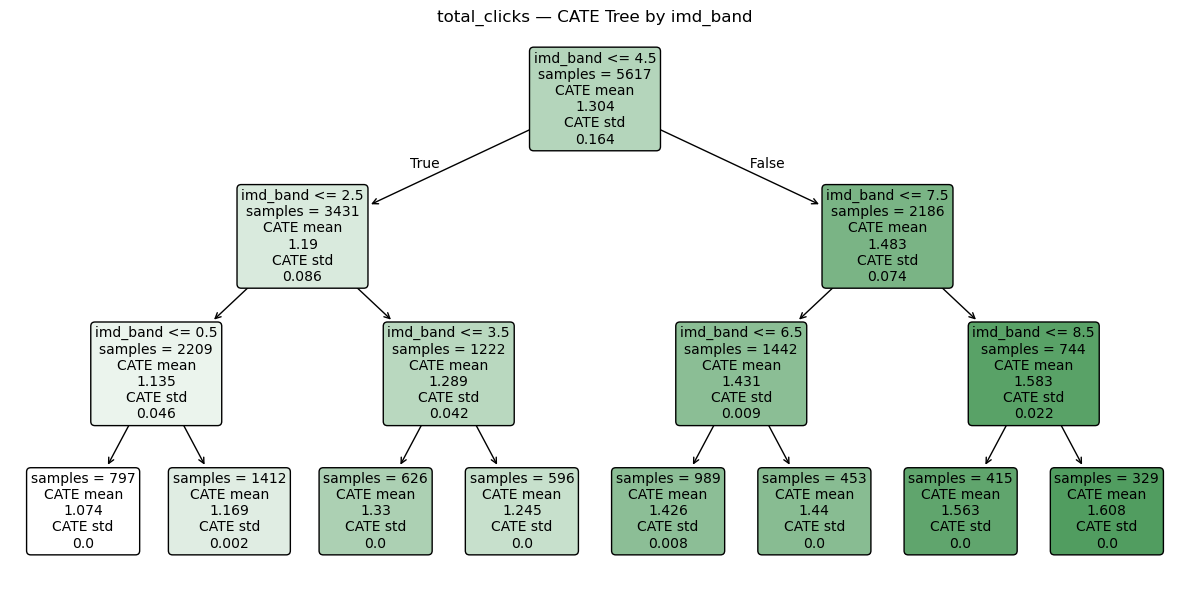

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_CATEtree_total_clicks_imd_band.png


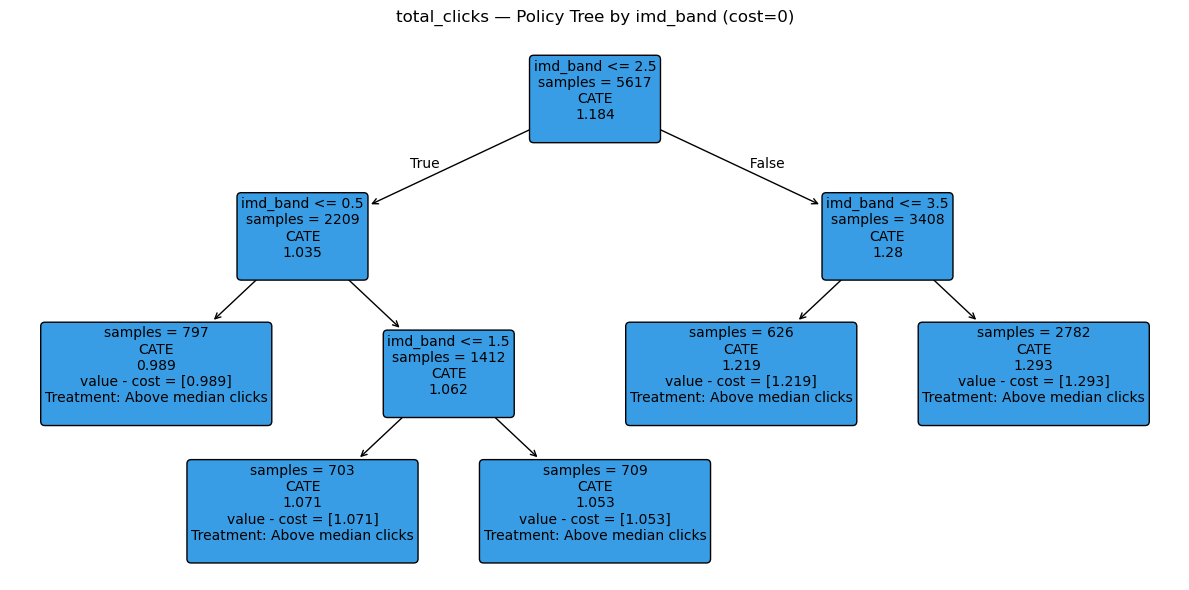

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_policy_total_clicks_imd_band.png


In [43]:
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter

treatment = 'total_clicks'
adj_set = adjustment_sets[treatment]

for moderator in moderators:
    W_cols = [c for c in adj_set if c != moderator]

    X = df_model[[moderator]].values
    T_binary = (df_model[treatment] >= df_model[treatment].median()).astype(int).values
    Y = df_model['final_result'].values
    W = df_model[W_cols].values if len(W_cols) > 0 else None

    est = CausalForestDML(random_state=42)
    est.fit(Y, T_binary, X=X, W=W)

    # CATE tree — shows heterogeneity structure
    cate_interpreter = SingleTreeCateInterpreter(include_model_uncertainty=False, max_depth=3)
    cate_interpreter.interpret(est, X)

    plt.figure(figsize=(12, 6))
    cate_interpreter.plot(feature_names=[moderator], fontsize=10)
    plt.title(f'total_clicks — CATE Tree by {moderator}')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"BBB_CATEtree_total_clicks_{moderator}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

    # Policy tree — cost=0, illustrative stand-in
    policy_interpreter = SingleTreePolicyInterpreter(risk_level=0.05, max_depth=3, min_samples_leaf=30)
    policy_interpreter.interpret(est, X, sample_treatment_costs=0)

    plt.figure(figsize=(12, 6))
    policy_interpreter.plot(feature_names=[moderator], treatment_names=['Below median clicks', 'Above median clicks'], fontsize=10)
    plt.title(f'total_clicks — Policy Tree by {moderator} (cost=0)')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"BBB_policy_total_clicks_{moderator}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## ATE heatmap 

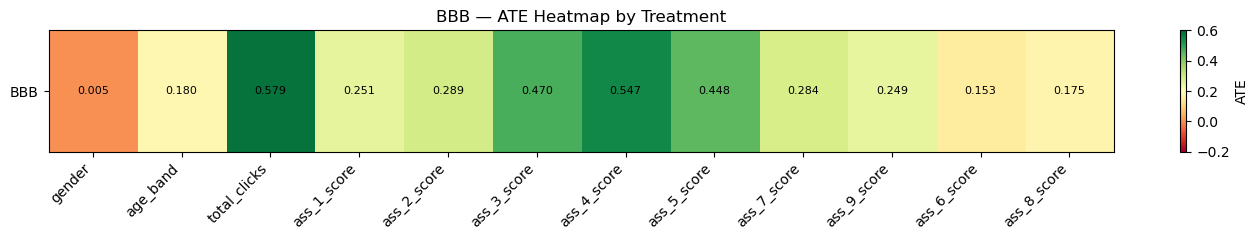

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_ATE_heatmap.png


In [47]:
heatmap_data = results_df.set_index('treatment')[['ATE']].T

plt.figure(figsize=(14, 2.5))
plt.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-0.2, vmax=0.6)
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha='right')
plt.yticks([0], ['BBB'])
plt.colorbar(label='ATE')

for i, val in enumerate(heatmap_data.values[0]):
    plt.text(i, 0, f'{val:.3f}', ha='center', va='center', fontsize=8)

plt.title('BBB — ATE Heatmap by Treatment')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "BBB_ATE_heatmap.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")

## DAG with ATE node overlay — manual fixed-position layout

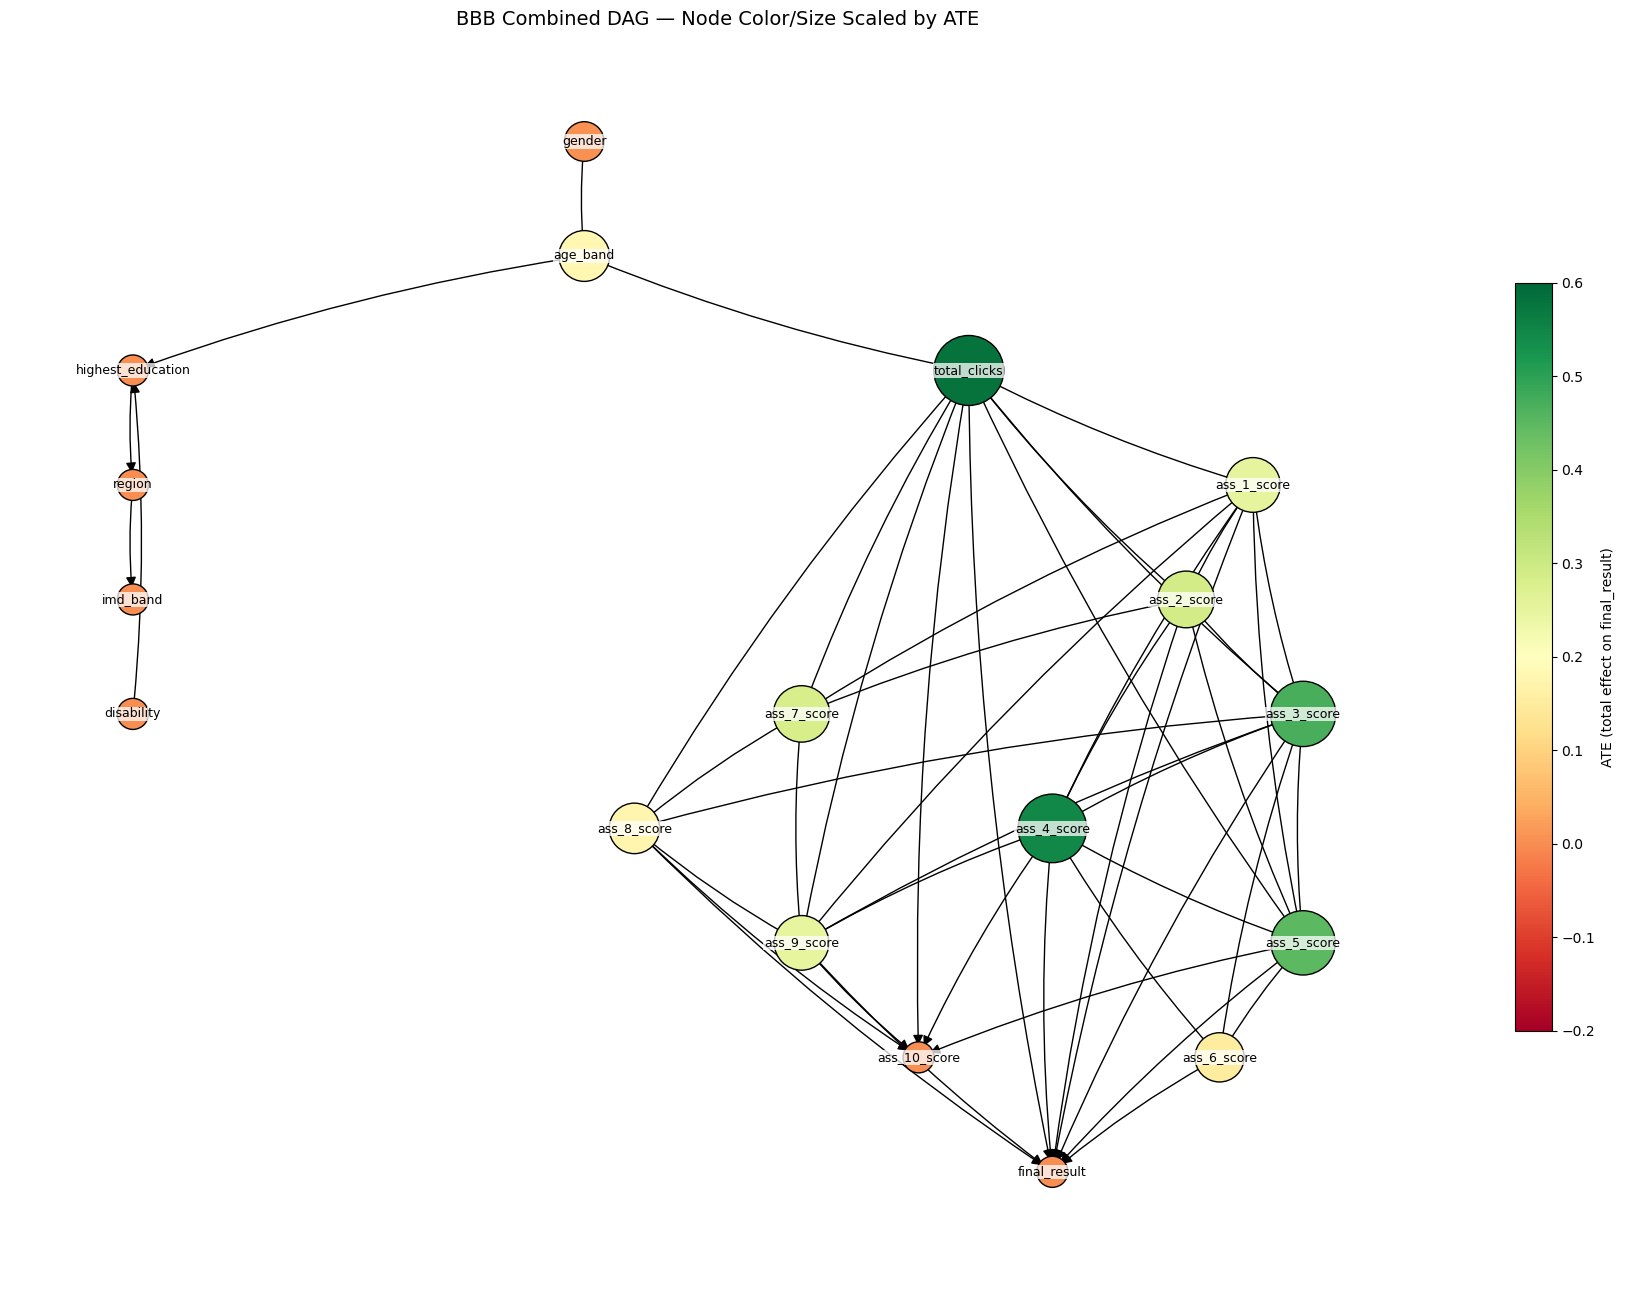

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_DAG_with_ATE.png


In [56]:
pos = {
    'gender': (3.2, 10),
    'num_of_prev_attempts': (5.5, 10),
    'ass_11_score': (7.8, 10),
    'age_band': (3.2, 8.8),
    'studied_credits': (5.5, 8.8),
    'highest_education': (0.5, 7.6),
    'total_clicks': (5.5, 7.6),
    'region': (0.5, 6.4),
    'ass_1_score': (7.2, 6.4),
    'imd_band': (0.5, 5.2),
    'ass_2_score': (6.8, 5.2),
    'disability': (0.5, 4.0),
    'ass_7_score': (4.5, 4.0),
    'ass_3_score': (7.5, 4.0),
    'ass_8_score': (3.5, 2.8),
    'ass_4_score': (6.0, 2.8),
    'ass_9_score': (4.5, 1.6),
    'ass_5_score': (7.5, 1.6),
    'ass_10_score': (5.2, 0.4),
    'ass_6_score': (7.0, 0.4),
    'final_result': (6.0, -0.8),
}

# Node color/size scaled by ATE magnitude (total-effect ATE, not per-edge coefficient)
ate_lookup = results_df.set_index('treatment')['ATE'].to_dict()

fig, ax = plt.subplots(figsize=(18, 13))

node_colors = []
node_sizes = []
for node in G.nodes():
    if node in ate_lookup:
        ate_val = ate_lookup[node]
        node_colors.append(ate_val)
        node_sizes.append(800 + abs(ate_val) * 3000)
    else:
        node_colors.append(0)
        node_sizes.append(500)

# final_result and demographic-cluster-only nodes not in ate_lookup get neutral color/size
nodes_to_draw = list(G.nodes())
missing_pos = [n for n in nodes_to_draw if n not in pos]
if missing_pos:
    print("WARNING — missing pos for:", missing_pos)

nx.draw_networkx_edges(G, pos, ax=ax, edge_color='black', arrows=True, arrowsize=15, alpha=1, connectionstyle='arc3,rad=0.05')

nc = nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                             cmap='RdYlGn', vmin=-0.2, vmax=0.6, edgecolors='black')

nx.draw_networkx_labels(G, pos, ax=ax, font_size=9,
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.5))

cbar = plt.colorbar(nc, ax=ax, shrink=0.6)
cbar.set_label('ATE (total effect on final_result)')

ax.set_title('BBB Combined DAG — Node Color/Size Scaled by ATE', fontsize=14)
ax.axis('off')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "BBB_DAG_with_ATE.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")